# Exploratory Data Analysis of UN data - GDP
We have UN open source data. This notebook will have an inital look into the data sources we have and visualise the information we have.

In [1]:
# import packages
from config import gdp_filename, input_folder_structure
from read_data import get_raw_dataset
from visual import visualise_gdp_per_capita

In [2]:
# initialise data frame
df = get_raw_dataset(
    input_folder_structure=input_folder_structure,
    input_filename=gdp_filename,
    type_of_data="gdp",
)
df.head(5)

,region_code,region_name,year,series,value,footnotes,source
0,1,"Total, all countries or areas",1995,GDP in current prices (millions of US dollars),31300091.0,NaN,"United Nations Statistics Division, New York, ..."
1,1,"Total, all countries or areas",2005,GDP in current prices (millions of US dollars),47928472.0,NaN,"United Nations Statistics Division, New York, ..."
2,1,"Total, all countries or areas",2010,GDP in current prices (millions of US dollars),66806397.0,NaN,"United Nations Statistics Division, New York, ..."
3,1,"Total, all countries or areas",2015,GDP in current prices (millions of US dollars),75630164.0,NaN,"United Nations Statistics Division, New York, ..."
4,1,"Total, all countries or areas",2020,GDP in current prices (millions of US dollars),85789779.0,NaN,"United Nations Statistics Division, New York, ..."


## Explore the data
It is good to understand the data before using it.

We will find the granularity of this dataset and some main attributes (variables that describe the data).

In [3]:
df["year"].unique()

array([1995, 2005, 2010, 2015, 2020, 2022, 2023])

In [4]:
# find out which regions are included in the dataset
df["region_name"].unique()

<StringArray>
['Total, all countries or areas',                        'Africa',
               'Northern Africa',            'Sub-Saharan Africa',
                'Eastern Africa',                 'Middle Africa',
               'Southern Africa',                'Western Africa',
                      'Americas',              'Northern America',
 ...
       'United Rep. of Tanzania',      'United States of America',
                       'Uruguay',                    'Uzbekistan',
                       'Vanuatu',    'Venezuela (Boliv. Rep. of)',
                      'Viet Nam',                         'Yemen',
                        'Zambia',                      'Zimbabwe']
Length: 243, dtype: str

In [5]:
df["series"].unique()

<StringArray>
[      'GDP in current prices (millions of US dollars)',
                          'GDP per capita (US dollars)',
 'GDP in constant 2015 prices (millions of US dollars)',
                   'GDP real rates of growth (percent)']
Length: 4, dtype: str

### Granularity
The dataset is a long form with each row having a year, a region_name and a series (the type of GDP series). This memans you will have to fliter two attributes to define a comparison.

## Trend analysis
We will now visualise the data. The variables that are in capitals can be changed to isolate a group of regions to compare and the choose a series to analyse.

In [6]:
# check whether regions are in the dataset
# This is sensitive to case
# change CHECK_NAME to see if the region is available in the dataset
CHECK_NAME = "America"


#
regions_in_df = df["region_name"].unique()
[name for name in regions_in_df if CHECK_NAME in name]

['Americas',
 'Northern America',
 'Latin America & the Caribbean',
 'Central America',
 'South America',
 'United States of America']

In [12]:
# Copy the names from above into this list
# Each region name has to be the same as it is found above
REGION_NAMES = [
    "Europe",
    "Northern America",
    "Latin America & the Caribbean",
    "Africa",
    "Asia",
]

In [8]:
series_to_choose_from = [
    "GDP in current prices (millions of US dollars)",  # 0
    "GDP per capita (US dollars)",  # 1
    "GDP in constant 2015 prices (millions of US dollars)",  # 2
    "GDP real rates of growth (percent)",  # 3
]
SERIES_CHOICE = series_to_choose_from[3]

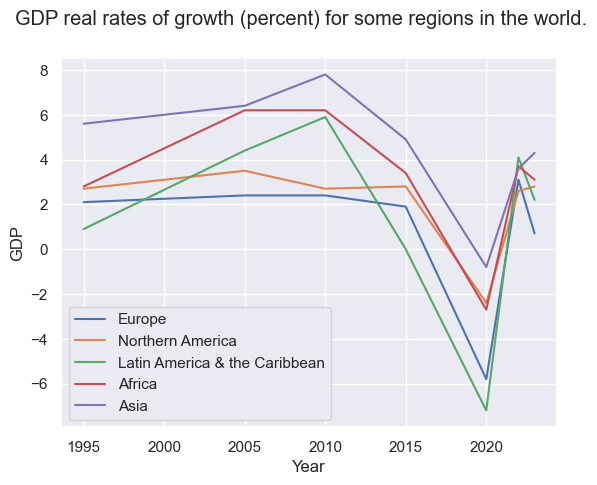

In [13]:
visualise_gdp_per_capita(
    df=df,
    country_names=REGION_NAMES,
    series_choice=SERIES_CHOICE,
)